# RADA Decay Rate Analysis by Chamber Location

This notebook performs exponential decay analysis on log-transformed fluorescence data and visualizes decay rates across chamber positions.

**Note:** Source data not included in the repository due to large file size, see below for instructions how to obtain it.

**Input:** `analysis_code/1_fluo_binary_metabolic_gradient.csv` (from `analysis_code/1_fluo_binary_metabolic_gradient.ipynb`)

**Output:** `S7B/S7B_metabolic_gradient.pdf`

**Generating source data:**
The source data file is not included in the repository due to large file size. To generate it:
1. Download the raw imaging data from BioImage Archive.
2. Run `analysis_code/0_combined_df_metabolic_gradient.ipynb` to combine raw data into a single dataframe.
3. Run `analysis_code/1_fluo_binary_metabolic_gradient.ipynb` to normalize, bin cells spatially, and save the cell-level CSV used by this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# Load cell-level data
df = pd.read_csv('../analysis_code/1_fluo_binary_metabolic_gradient.csv')


In [3]:
# Filter to first 3 hours (exponential decay phase)
df_decay = df[df['time_hours'] <= 3].copy()
df_decay['log_intensity'] = np.log(df_decay['intensity_raw_mcherry'])

# Compute summary statistics for log data (used for error bands)
summary_log = df_decay.groupby(['y_bin_label', 'time_hours'])['log_intensity'] \
                     .agg(mean='mean', std='std').reset_index()

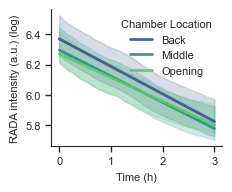

In [4]:
# Set plotting style
sns.set_style("white")
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 8

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(6/2.54, 5/2.54))  # 6 cm × 5 cm

# Prepare colors and positions
bins_sorted = ['Back', 'Middle', 'Opening']
palette = sns.color_palette("viridis", n_colors=len(bins_sorted))

# Log-transformed data with linear fits
fit_results = {}

for i, bin_label in enumerate(bins_sorted):
    # Get summary data for error bands
    subset_log = summary_log[summary_log['y_bin_label'] == bin_label]
    x_data = subset_log['time_hours'].to_numpy()
    y_data = subset_log['mean'].to_numpy()
    y_std = subset_log['std'].to_numpy()

    # Fit linear regression to individual data points
    individual_data = df_decay[df_decay['y_bin_label'] == bin_label]
    X = individual_data['time_hours'].values.reshape(-1, 1)
    y_individual = individual_data['log_intensity'].values

    model = LinearRegression().fit(X, y_individual)

    # Generate smooth fit line
    x_smooth = np.linspace(0, 3, 50)
    y_fit = model.predict(x_smooth.reshape(-1, 1))

    # Plot fit line with matching color
    ax.plot(x_smooth, y_fit, '-', color=palette[i], linewidth=2, alpha=0.9, label=f'{bin_label}')

    # Add error shadow around the actual data points
    ax.fill_between(x_data, y_data - y_std, y_data + y_std, color=palette[i], alpha=0.2)

    # Store results
    r_squared = r2_score(y_individual, model.predict(X))
    decay_rate = -model.coef_[0]  # Convert slope to positive decay rate
    initial_intensity = np.exp(model.intercept_)

    fit_results[bin_label] = {
        'decay_rate': decay_rate,
        'initial_intensity': initial_intensity,
        'r_squared': r_squared,
        'slope': model.coef_[0],
        'intercept': model.intercept_
    }

ax.set_xlabel('Time (h)')
ax.set_ylabel('RADA intensity (a.u.) (log)')
ax.legend(title='Chamber Location',frameon=False, loc='upper right')

# Style plot
ax.tick_params(axis='x', which='both', direction='out', bottom=True, top=False, length=4, width=1)
ax.tick_params(axis='y', which='both', direction='out', left=True, right=False, length=4, width=1)
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()

# Export to PDF for Illustrator
plt.savefig('S7B_metabolic_gradient.pdf', format='pdf', dpi=300)
plt.show()

In [5]:
# Display fit results
print("\n" + "="*60)
print("LINEAR REGRESSION RESULTS (First 3 hours)")
print("="*60)
print(f"{'Position':<12} {'Decay Rate':<12} {'Initial Int.':<12} {'R²':<8}")
print("-" * 60)

for position in bins_sorted:
    params = fit_results[position]
    print(f"{position:<12} {params['decay_rate']:.4f} h⁻¹   {params['initial_intensity']:.1f}      {params['r_squared']:.3f}")


LINEAR REGRESSION RESULTS (First 3 hours)
Position     Decay Rate   Initial Int. R²      
------------------------------------------------------------
Back         0.1825 h⁻¹   584.5      0.620
Middle       0.1735 h⁻¹   542.8      0.642
Opening      0.1576 h⁻¹   529.5      0.659


In [6]:
# Compare decay rates between positions
print(f"\nFold differences in decay rates:")
print(f"Back vs Opening: {fit_results['Back']['decay_rate']/fit_results['Opening']['decay_rate']:.2f}x faster")
print(f"Back vs Middle: {fit_results['Back']['decay_rate']/fit_results['Middle']['decay_rate']:.2f}x faster") 
print(f"Middle vs Opening: {fit_results['Middle']['decay_rate']/fit_results['Opening']['decay_rate']:.2f}x faster")

print(f"\nInitial intensity differences:")
print(f"Back vs Opening: {fit_results['Back']['initial_intensity']/fit_results['Opening']['initial_intensity']:.2f}x higher")
print(f"Back vs Middle: {fit_results['Back']['initial_intensity']/fit_results['Middle']['initial_intensity']:.2f}x higher")
print(f"Middle vs Opening: {fit_results['Middle']['initial_intensity']/fit_results['Opening']['initial_intensity']:.2f}x higher")


Fold differences in decay rates:
Back vs Opening: 1.16x faster
Back vs Middle: 1.05x faster
Middle vs Opening: 1.10x faster

Initial intensity differences:
Back vs Opening: 1.10x higher
Back vs Middle: 1.08x higher
Middle vs Opening: 1.03x higher
